# 🏪 Inventory Forecasting — Complete ML Project
**Dataset:** `inventory_forecast_dataset_v2.csv`  
**Columns:** Product_Name, Category, Date, Units_Sold  
**Models:** ARIMA, XGBoost, Prophet  
**Goal:** Forecast next 30 days demand per product

---
## 📋 Project Phases
1. Data Loading & Exploration
2. EDA & Visualization
3. Feature Engineering
4. Model Building (ARIMA + XGBoost + Prophet)
5. Model Evaluation & Comparison
6. Hyperparameter Tuning
7. Final Forecast & Business Insights
8. Model Saving

# Phase 1: Library Import & Data Loading

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import matplotlib.dates as mdates
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
import joblib

In [2]:
# ── Load Dataset ─────────────────────────────────────────────────
# UPDATE THIS PATH if needed
DATA_PATH = 'inventory_forecast_dataset_v2.csv'

df = pd.read_csv(DATA_PATH, parse_dates=['Date'])
df = df.sort_values(['Product_Name', 'Date']).reset_index(drop=True)

print('=' * 55)
print('📊 DATASET OVERVIEW')
print('=' * 55)
print(f'Total rows       : {len(df):,}')
print(f'Unique Products  : {df["Product_Name"].nunique()}')
print(f'Unique Categories: {df["Category"].nunique()}')
print(f'Date Range       : {df["Date"].min().date()} → {df["Date"].max().date()}')
print(f'Missing Values   : {df.isnull().sum().sum()}')
print('=' * 55)
df.head(10)

📊 DATASET OVERVIEW
Total rows       : 25,664
Unique Products  : 32
Unique Categories: 9
Date Range       : 2023-01-01 → 2025-03-12
Missing Values   : 0


,Product_Name,Category,Date,Units_Sold
0,Bananas,Fruits & Vegetables,2023-01-01,296
1,Bananas,Fruits & Vegetables,2023-01-02,145
2,Bananas,Fruits & Vegetables,2023-01-03,152
3,Bananas,Fruits & Vegetables,2023-01-04,174
4,Bananas,Fruits & Vegetables,2023-01-05,169
5,Bananas,Fruits & Vegetables,2023-01-06,160
6,Bananas,Fruits & Vegetables,2023-01-07,195
7,Bananas,Fruits & Vegetables,2023-01-08,217
8,Bananas,Fruits & Vegetables,2023-01-09,161
9,Bananas,Fruits & Vegetables,2023-01-10,168


In [3]:
# ── Basic Statistics ──────────────────────────────────────────────
print('📈 Units_Sold Statistics:')
print(df['Units_Sold'].describe().round(2))

print('\n📦 Products by Category:')
cat_summary = df.groupby('Category')['Product_Name'].nunique().sort_values(ascending=False)
print(cat_summary.to_string())

print('\n🛒 All Products:')
print(sorted(df['Product_Name'].unique()))

📈 Units_Sold Statistics:
count    25664.00
mean       121.11
std         57.64
min          8.00
25%         76.00
50%        108.00
75%        156.00
max        455.00
Name: Units_Sold, dtype: float64

📦 Products by Category:
Category
Fruits & Vegetables       6
Meat & Seafood            4
Dairy & Eggs              4
Grains & Staples          4
Beverages                 3
Oils & Fats               3
Condiments & Spices       3
Snacks & Confectionery    3
Frozen Foods              2

🛒 All Products:
['Bananas', 'Bell Pepper', 'Butter (250g)', 'Cheddar Cheese', 'Chicken Breast', 'Cumin Powder', 'Dark Chocolate', 'Eggs (12pk)', 'Frozen Peas (500g)', 'Frozen Pizza', 'Greek Yogurt', 'Green Tea (20pk)', 'Ground Beef', 'Honey (500g)', 'Milk (1L)', 'Mineral Water (2L)', 'Oats (1kg)', 'Olive Oil', 'Onions', 'Orange Juice (1L)', 'Pasta (500g)', 'Potato Chips', 'Potatoes', 'Rice (5kg)', 'Salmon Fillet', 'Soy Sauce (300ml)', 'Spinach', 'Tomato Ketchup', 'Tomatoes', 'Tuna (Canned)', 'Vegetable Oil

# Phase 2: EDA & Visualization

C:\Users\BAPS\AppData\Local\Temp\ipykernel_4556\1603801741.py:16: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\BAPS\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


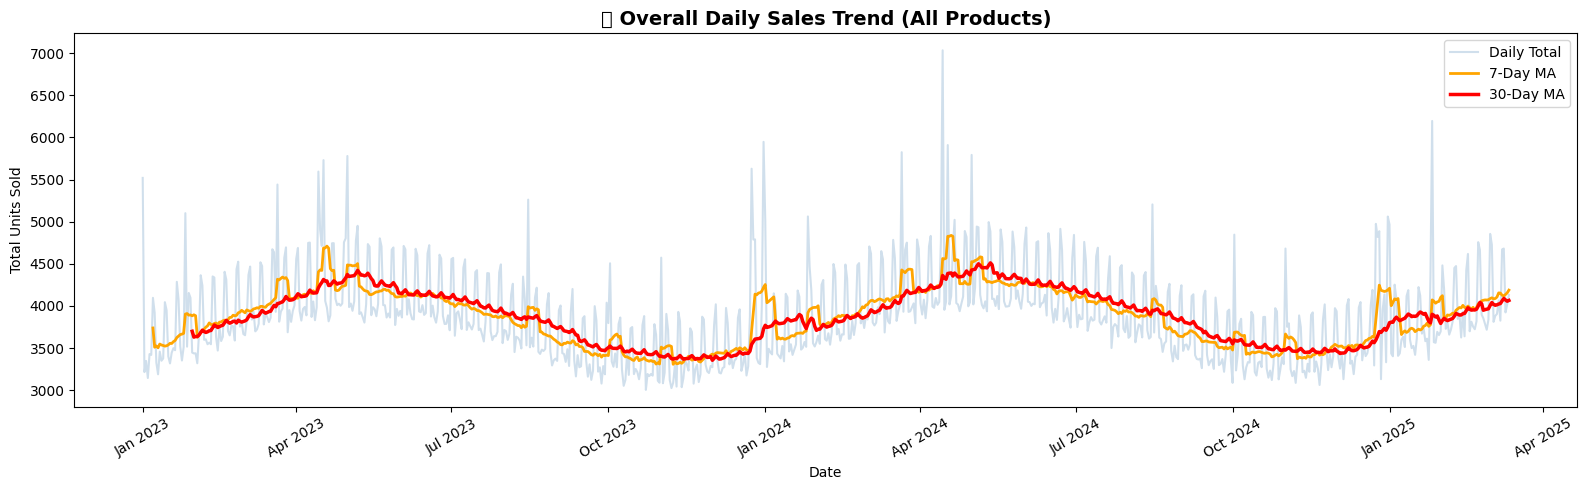

In [4]:


# ── Overall Sales Trend ───────────────────────────────────────────
daily_total = df.groupby('Date')['Units_Sold'].sum().reset_index()
daily_total['rolling_7d'] = daily_total['Units_Sold'].rolling(7).mean()
daily_total['rolling_30d'] = daily_total['Units_Sold'].rolling(30).mean()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(daily_total['Date'], daily_total['Units_Sold'], alpha=0.25, color='steelblue', label='Daily Total')
ax.plot(daily_total['Date'], daily_total['rolling_7d'], color='orange', linewidth=2, label='7-Day MA')
ax.plot(daily_total['Date'], daily_total['rolling_30d'], color='red', linewidth=2.5, label='30-Day MA')
ax.set_title('📦 Overall Daily Sales Trend (All Products)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Total Units Sold')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

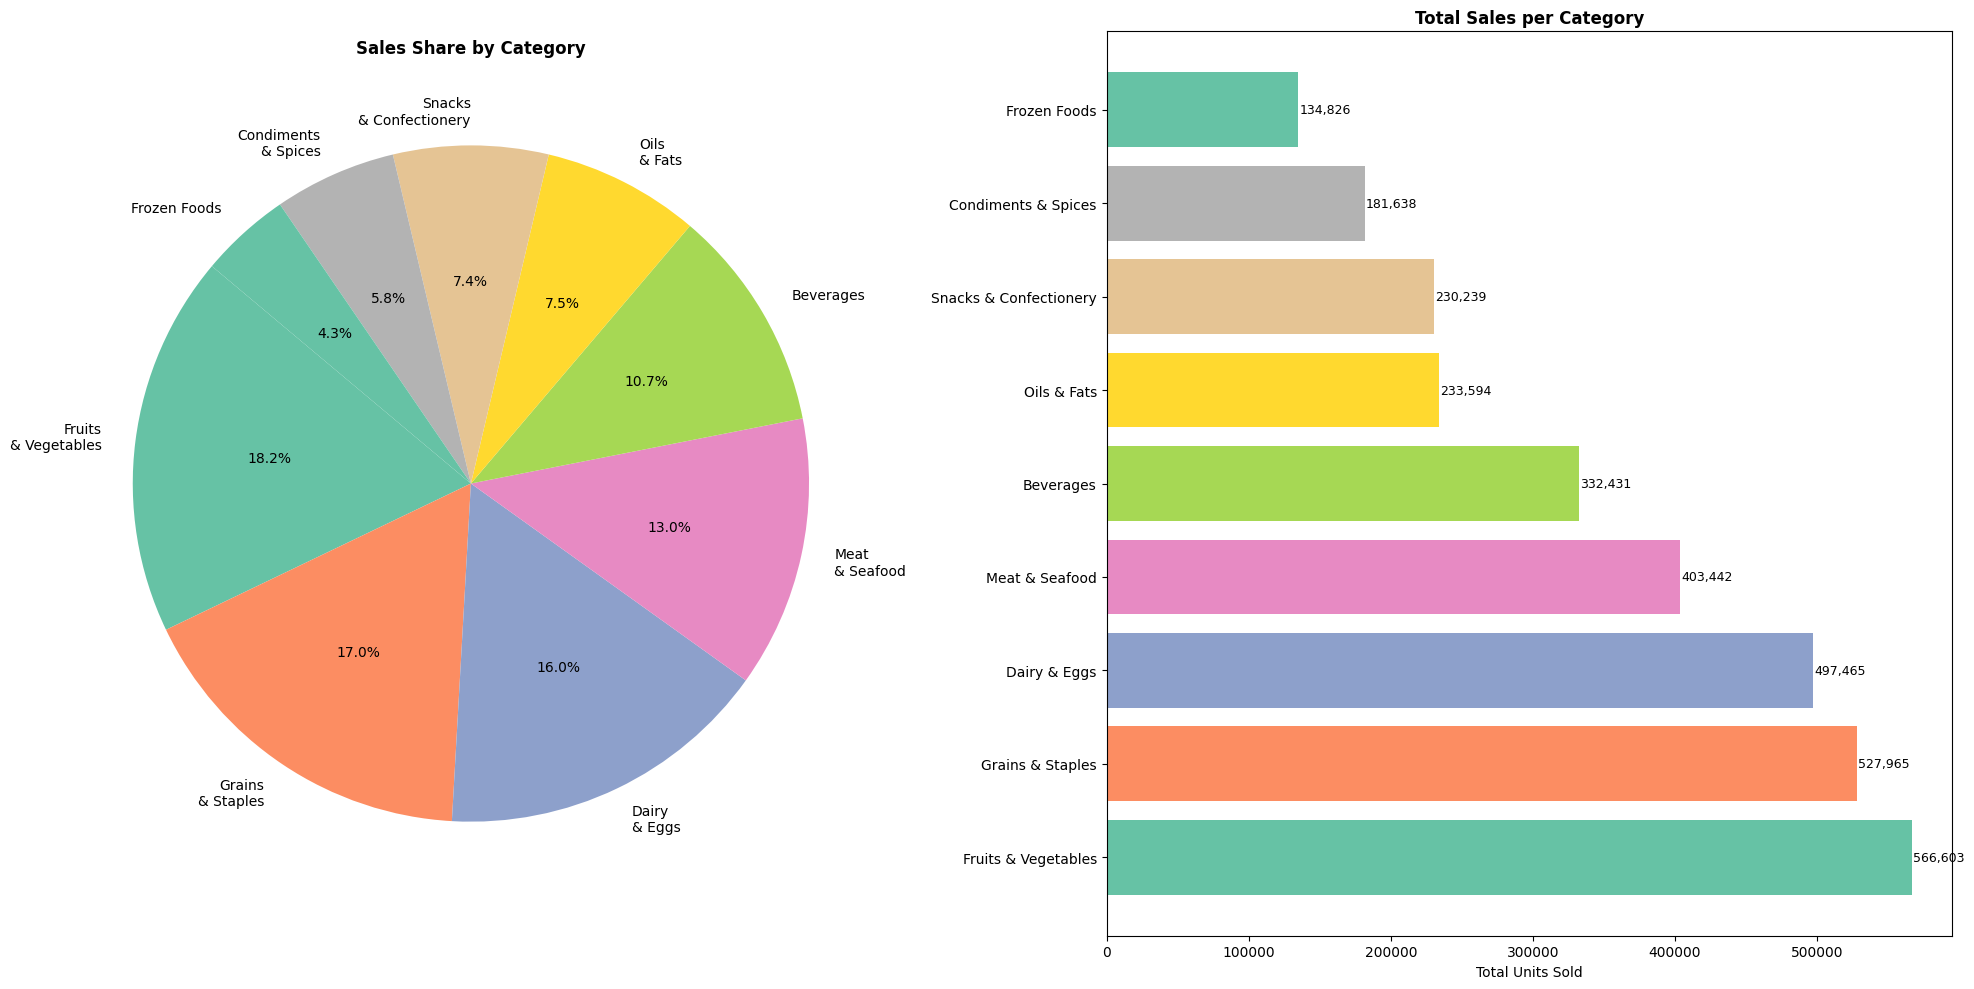

In [5]:
# ── Sales by Category ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Pie chart
cat_sales = df.groupby('Category')['Units_Sold'].sum().sort_values(ascending=False)
axes[0].pie(cat_sales.values, labels=[c.replace(' & ', '\n& ') for c in cat_sales.index],
            autopct='%1.1f%%', startangle=140,
            colors=sns.color_palette('Set2', len(cat_sales)))
axes[0].set_title('Sales Share by Category', fontweight='bold')

# Bar chart
axes[1].barh(cat_sales.index, cat_sales.values,
             color=sns.color_palette('Set2', len(cat_sales)))
axes[1].set_xlabel('Total Units Sold')
axes[1].set_title('Total Sales per Category', fontweight='bold')
for i, v in enumerate(cat_sales.values):
    axes[1].text(v + 1000, i, f'{v:,}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

C:\Users\BAPS\AppData\Local\Temp\ipykernel_4556\4065047746.py:23: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\BAPS\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


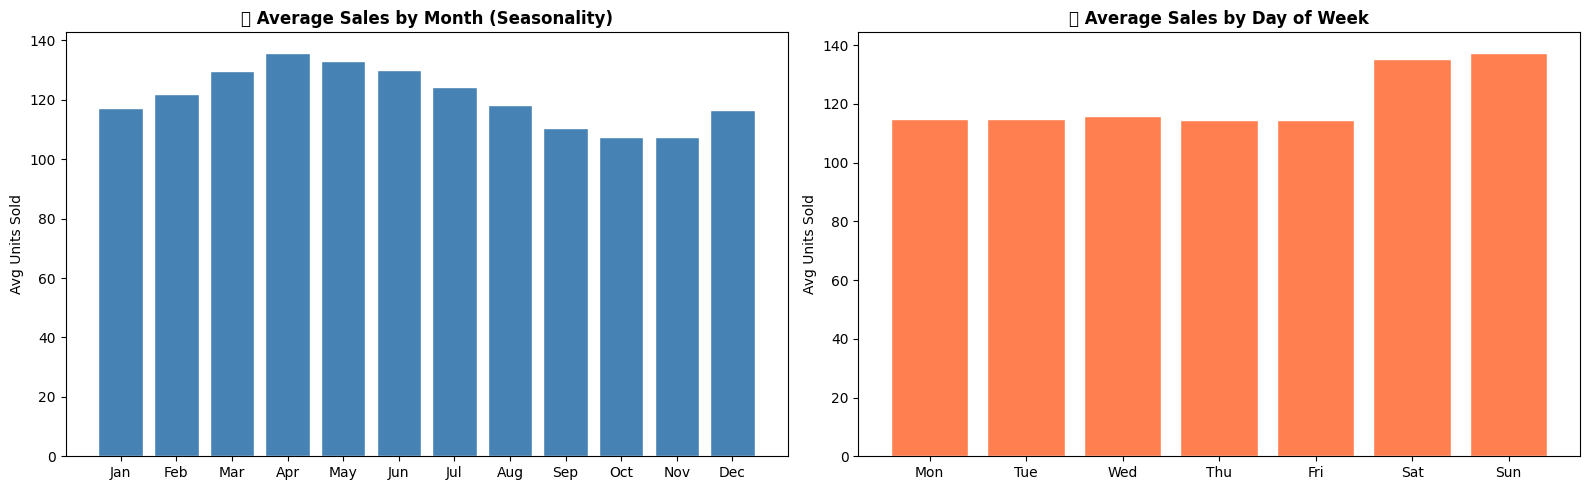

In [6]:
# ── Seasonality Analysis ──────────────────────────────────────────
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['WeekNum'] = df['Date'].dt.isocalendar().week.astype(int)
df['Year'] = df['Date'].dt.year

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Monthly pattern
month_sales = df.groupby('Month')['Units_Sold'].mean()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
axes[0].bar(month_names, month_sales.values, color='steelblue', edgecolor='white')
axes[0].set_title('📅 Average Sales by Month (Seasonality)', fontweight='bold')
axes[0].set_ylabel('Avg Units Sold')

# Day-of-week pattern
dow_sales = df.groupby('DayOfWeek')['Units_Sold'].mean()
day_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
axes[1].bar(day_names, dow_sales.values, color='coral', edgecolor='white')
axes[1].set_title('📅 Average Sales by Day of Week', fontweight='bold')
axes[1].set_ylabel('Avg Units Sold')

plt.tight_layout()
plt.show()

C:\Users\BAPS\AppData\Local\Temp\ipykernel_4556\214376640.py:20: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\BAPS\AppData\Local\Temp\ipykernel_4556\214376640.py:20: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\BAPS\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\BAPS\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


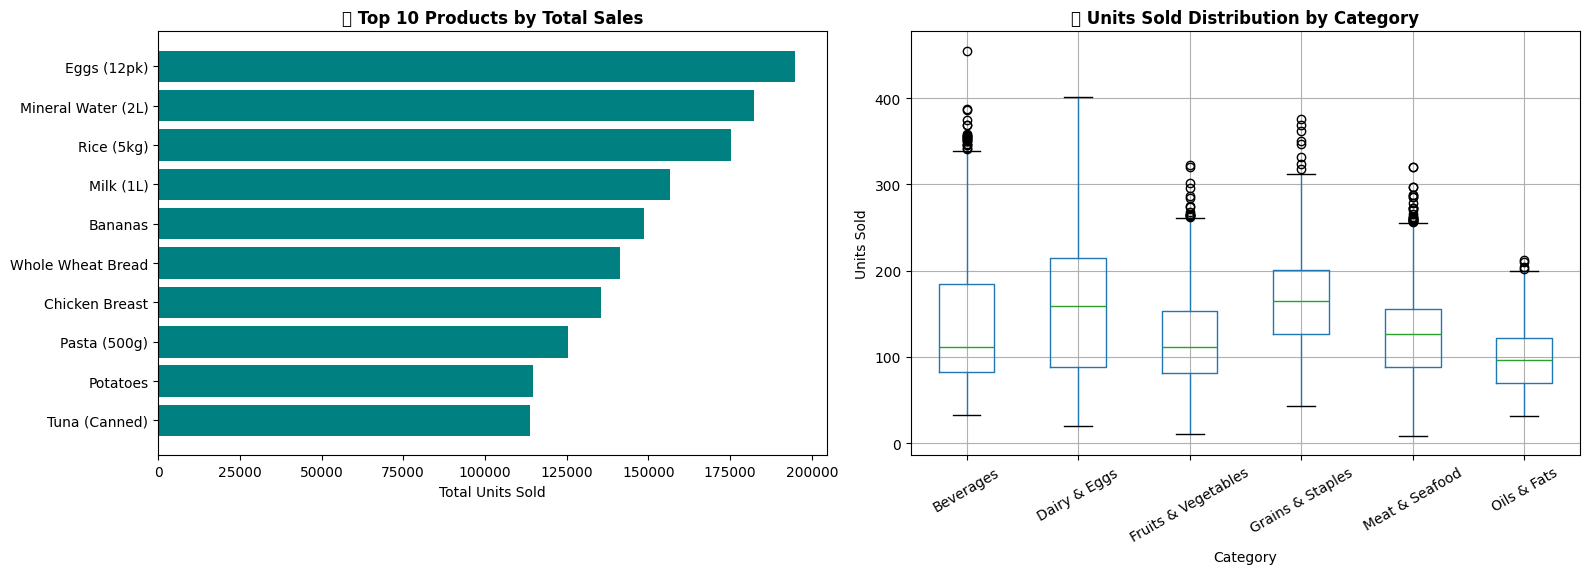


🔍 Outliers detected (IQR method): 370 rows (1.4%)


In [7]:
# ── Top Products & Outlier Detection ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 10 products
top10 = df.groupby('Product_Name')['Units_Sold'].sum().sort_values(ascending=True).tail(10)
axes[0].barh(top10.index, top10.values, color='teal')
axes[0].set_title('🏆 Top 10 Products by Total Sales', fontweight='bold')
axes[0].set_xlabel('Total Units Sold')

# Box plot for outlier detection
top6_cats = df.groupby('Category')['Units_Sold'].sum().nlargest(6).index
df_top = df[df['Category'].isin(top6_cats)]
df_top.boxplot(column='Units_Sold', by='Category', ax=axes[1],
               rot=30, grid=True)
axes[1].set_title('📊 Units Sold Distribution by Category', fontweight='bold')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Units Sold')
plt.suptitle('')

plt.tight_layout()
plt.show()

# IQR Outlier count
Q1 = df['Units_Sold'].quantile(0.25)
Q3 = df['Units_Sold'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['Units_Sold'] < Q1 - 1.5*IQR) | (df['Units_Sold'] > Q3 + 1.5*IQR)]
print(f'\n🔍 Outliers detected (IQR method): {len(outliers)} rows ({len(outliers)/len(df)*100:.1f}%)')

C:\Users\BAPS\AppData\Local\Temp\ipykernel_4556\1552216694.py:6: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  prod_df = prod_df.asfreq('D').fillna(method='ffill')
C:\Users\BAPS\AppData\Local\Temp\ipykernel_4556\1552216694.py:14: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\BAPS\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


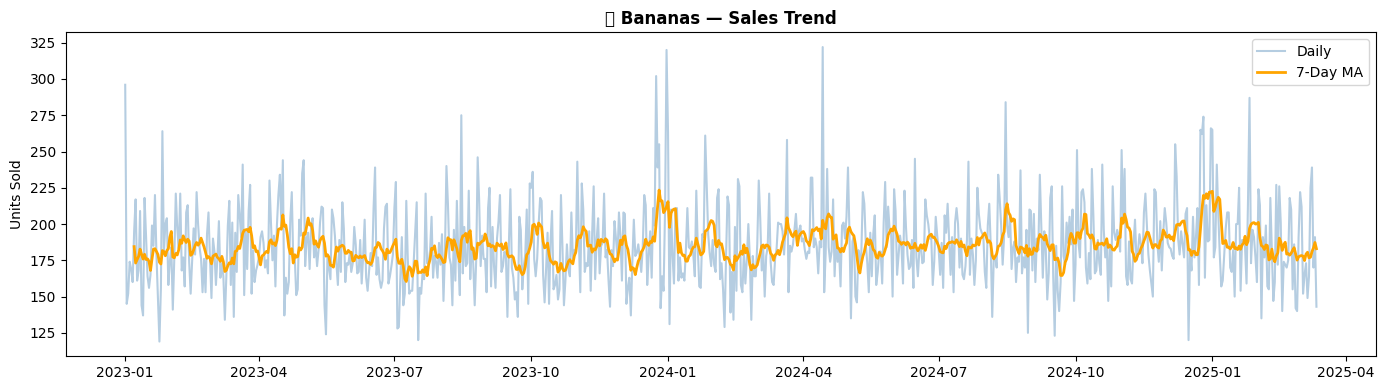

In [8]:
# ── Individual Product Trend ──────────────────────────────────────
# Pick one product to explore in detail
FOCUS_PRODUCT = 'Bananas'   # ← Change to any product name

prod_df = df[df['Product_Name'] == FOCUS_PRODUCT][['Date', 'Units_Sold']].set_index('Date')
prod_df = prod_df.asfreq('D').fillna(method='ffill')

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(prod_df.index, prod_df['Units_Sold'], alpha=0.4, color='steelblue', label='Daily')
ax.plot(prod_df.index, prod_df['Units_Sold'].rolling(7).mean(), color='orange', linewidth=2, label='7-Day MA')
ax.set_title(f'📦 {FOCUS_PRODUCT} — Sales Trend', fontweight='bold')
ax.set_ylabel('Units Sold')
ax.legend()
plt.tight_layout()
plt.show()

C:\Users\BAPS\AppData\Local\Temp\ipykernel_4556\3143997936.py:11: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\BAPS\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\BAPS\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


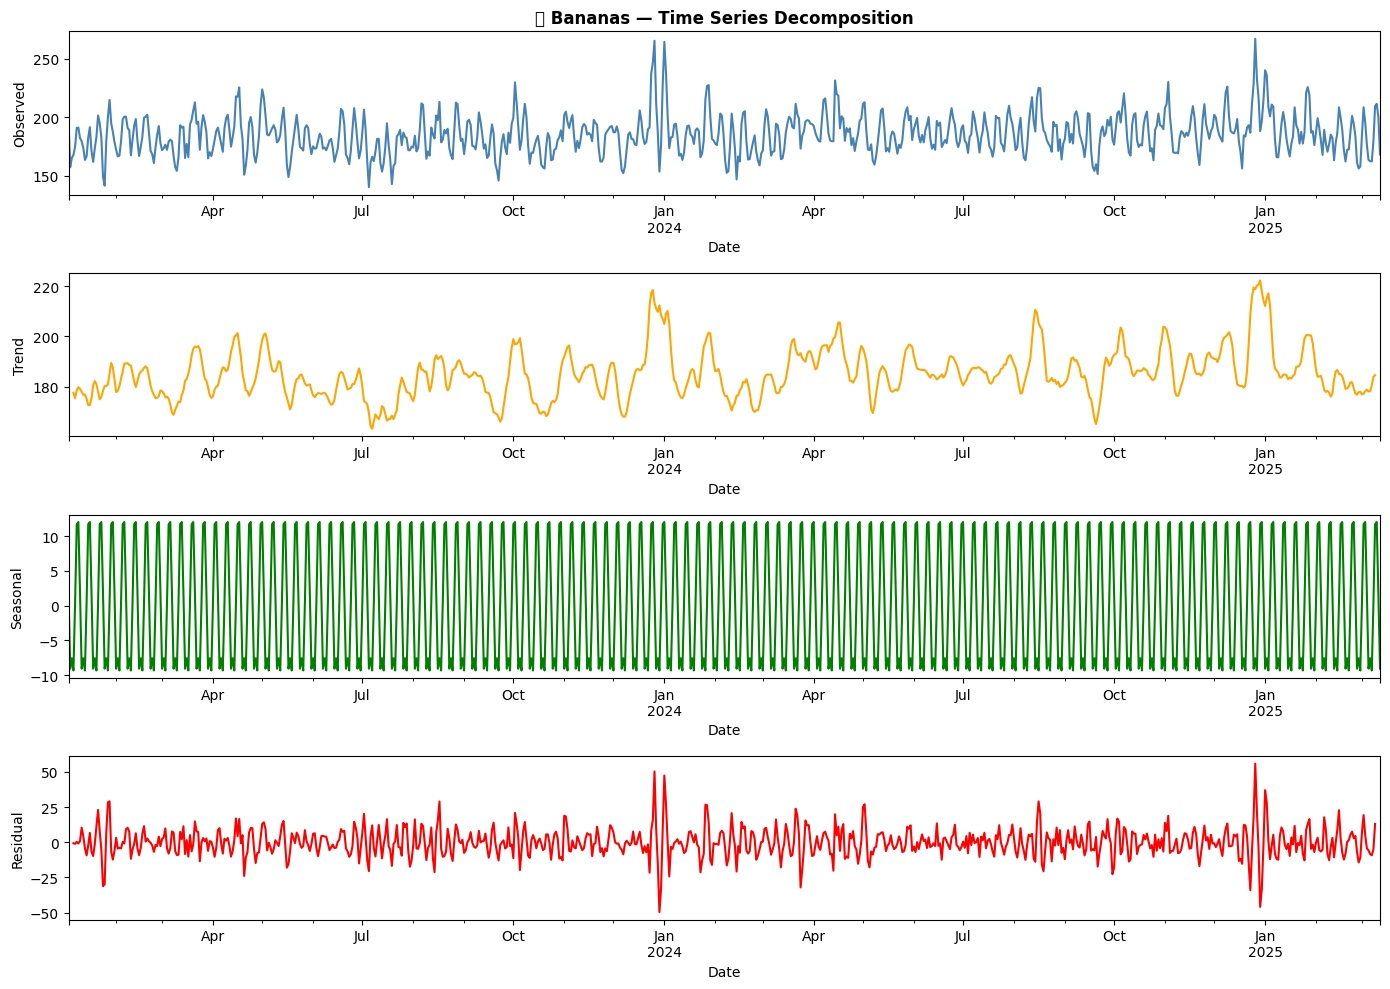

In [9]:
# ── Time Series Decomposition ─────────────────────────────────────
decomp_series = prod_df['Units_Sold'].rolling(3).mean().dropna()
decomposition = seasonal_decompose(decomp_series, model='additive', period=7)

fig, axes = plt.subplots(4, 1, figsize=(14, 10))
decomposition.observed.plot(ax=axes[0], color='steelblue'); axes[0].set_ylabel('Observed')
decomposition.trend.plot(ax=axes[1], color='orange');       axes[1].set_ylabel('Trend')
decomposition.seasonal.plot(ax=axes[2], color='green');     axes[2].set_ylabel('Seasonal')
decomposition.resid.plot(ax=axes[3], color='red');          axes[3].set_ylabel('Residual')
axes[0].set_title(f'📊 {FOCUS_PRODUCT} — Time Series Decomposition', fontweight='bold')
plt.tight_layout()
plt.show()

# Phase 3: Feature Engineering

In [10]:
def create_features(group):
    """Create lag, rolling, and calendar features for one product."""
    g = group.copy().sort_values('Date')
    g = g.set_index('Date').asfreq('D')
    g['Units_Sold'] = g['Units_Sold'].fillna(method='ffill').fillna(0)

    # Lag features
    for lag in [1, 3, 7, 14, 21, 30]:
        g[f'lag_{lag}'] = g['Units_Sold'].shift(lag)

    # Rolling statistics
    for window in [7, 14, 30]:
        g[f'rolling_mean_{window}'] = g['Units_Sold'].shift(1).rolling(window).mean()
        g[f'rolling_std_{window}']  = g['Units_Sold'].shift(1).rolling(window).std()
        g[f'rolling_max_{window}']  = g['Units_Sold'].shift(1).rolling(window).max()

    # Calendar features
    g['day_of_week']  = g.index.dayofweek
    g['month']        = g.index.month
    g['quarter']      = g.index.quarter
    g['day_of_month'] = g.index.day
    g['week_of_year'] = g.index.isocalendar().week.astype(int)
    g['is_weekend']   = (g.index.dayofweek >= 5).astype(int)
    g['is_month_end'] = g.index.is_month_end.astype(int)
    g['is_month_start'] = g.index.is_month_start.astype(int)

    # Trend features
    g['trend'] = np.arange(len(g))
    g['trend_squared'] = g['trend'] ** 2

    return g.reset_index()

# Apply to all products
feat_df = df.groupby('Product_Name', group_keys=False).apply(create_features)
feat_df = feat_df.dropna().reset_index(drop=True)

# Encode categorical
le_product  = LabelEncoder()
le_category = LabelEncoder()
feat_df['product_enc']  = le_product.fit_transform(feat_df['Product_Name'])
feat_df['category_enc'] = le_category.fit_transform(feat_df['Category'])

print(f'✅ Feature engineering complete!')
print(f'Shape: {feat_df.shape}')
print(f'Features created: {feat_df.shape[1] - 4} columns')
feat_df.head(3)

C:\Users\BAPS\AppData\Local\Temp\ipykernel_4556\3374133496.py:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  g['Units_Sold'] = g['Units_Sold'].fillna(method='ffill').fillna(0)
C:\Users\BAPS\AppData\Local\Temp\ipykernel_4556\3374133496.py:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  g['Units_Sold'] = g['Units_Sold'].fillna(method='ffill').fillna(0)
C:\Users\BAPS\AppData\Local\Temp\ipykernel_4556\3374133496.py:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  g['Units_Sold'] = g['Units_Sold'].fillna(method='ffill').fillna(0)
C:\Users\BAPS\AppData\Local\Temp\ipykernel_4556\3374133496.py:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
 

✅ Feature engineering complete!
Shape: (24704, 35)
Features created: 31 columns


C:\Users\BAPS\AppData\Local\Temp\ipykernel_4556\3374133496.py:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  g['Units_Sold'] = g['Units_Sold'].fillna(method='ffill').fillna(0)
C:\Users\BAPS\AppData\Local\Temp\ipykernel_4556\3374133496.py:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  g['Units_Sold'] = g['Units_Sold'].fillna(method='ffill').fillna(0)
C:\Users\BAPS\AppData\Local\Temp\ipykernel_4556\3374133496.py:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  g['Units_Sold'] = g['Units_Sold'].fillna(method='ffill').fillna(0)
C:\Users\BAPS\AppData\Local\Temp\ipykernel_4556\3374133496.py:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
 

,Date,Product_Name,Category,Units_Sold,Month,DayOfWeek,WeekNum,Year,lag_1,lag_3,...,quarter,day_of_month,week_of_year,is_weekend,is_month_end,is_month_start,trend,trend_squared,product_enc,category_enc
0,2023-01-31,Bananas,Fruits & Vegetables,174,1,1,5,2023,158.0,200.0,...,1,31,5,0,1,0,30,900,0,4
1,2023-02-01,Bananas,Fruits & Vegetables,184,2,2,5,2023,174.0,204.0,...,1,1,5,0,0,1,31,961,0,4
2,2023-02-02,Bananas,Fruits & Vegetables,141,2,3,5,2023,184.0,158.0,...,1,2,5,0,0,0,32,1024,0,4


C:\Users\BAPS\AppData\Local\Temp\ipykernel_4556\3581177072.py:12: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\BAPS\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


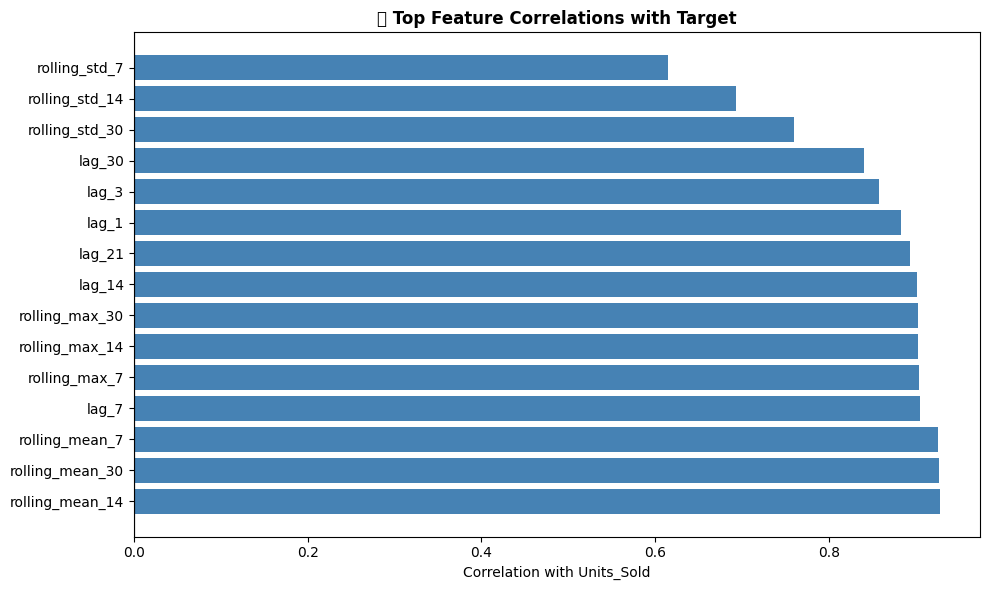

In [11]:
# ── Feature Correlation with Target ──────────────────────────────
numeric_cols = feat_df.select_dtypes(include=[np.number]).columns.tolist()
corr_with_target = feat_df[numeric_cols].corr()['Units_Sold'].drop('Units_Sold')
top_corr = corr_with_target.abs().sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
colors = ['steelblue' if v > 0 else 'coral' for v in corr_with_target[top_corr.index]]
plt.barh(top_corr.index, corr_with_target[top_corr.index].values, color=colors)
plt.xlabel('Correlation with Units_Sold')
plt.title('🔗 Top Feature Correlations with Target', fontweight='bold')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

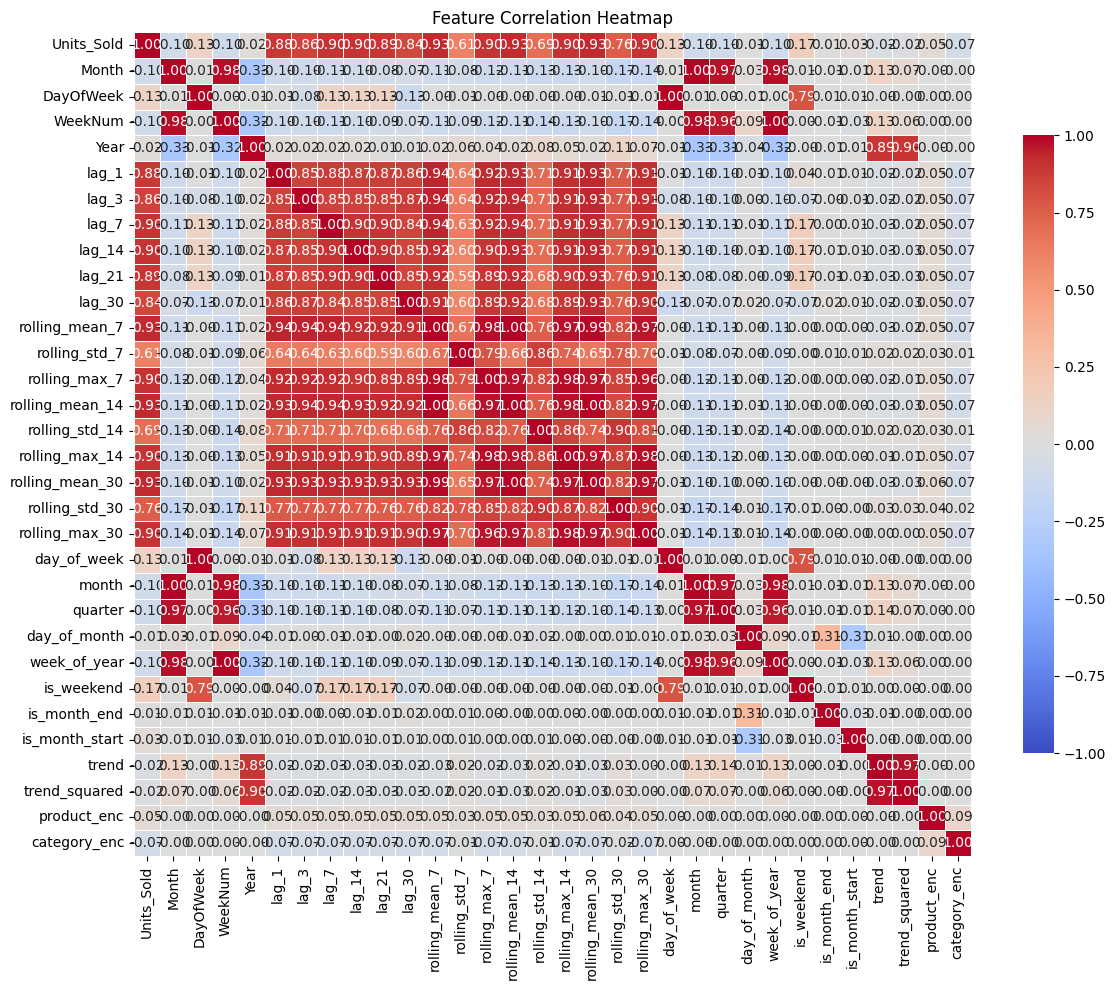

In [12]:
# Use feature correlations rather than full raw table
corr = feat_df.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            vmin=-1, vmax=1,
            linewidths=0.5,
            cbar_kws={"shrink": 0.75})
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

#  Phase 4: Model Building
### 4A — ARIMA (per-product time series model)

In [13]:
# ── ARIMA on FOCUS_PRODUCT ────────────────────────────────────────
FOCUS_PRODUCT = 'Bananas'   # ← Change as needed
FORECAST_DAYS = 30

prod_series = df[df['Product_Name'] == FOCUS_PRODUCT][['Date','Units_Sold']]\
    .set_index('Date').asfreq('D').fillna(method='ffill')['Units_Sold']

# Train / test split
train_end   = int(len(prod_series) * 0.85)
train_arima = prod_series.iloc[:train_end]
test_arima  = prod_series.iloc[train_end:]

# ADF Test (stationarity check)
adf_result = adfuller(train_arima)
print(f'ADF p-value: {adf_result[1]:.4f} — {"Stationary ✅" if adf_result[1]<0.05 else "Non-stationary ⚠️"}')

# Fit SARIMA model
print('\n⏳ Fitting SARIMA(1,1,1)(1,1,1,7)...')
sarima_model = SARIMAX(
    train_arima,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_fit = sarima_model.fit(disp=False)

# Predict on test set
test_pred_arima = sarima_fit.get_forecast(steps=len(test_arima))
pred_arima_mean = test_pred_arima.predicted_mean
pred_arima_ci   = test_pred_arima.conf_int()

arima_mae  = mean_absolute_error(test_arima, pred_arima_mean)
arima_rmse = np.sqrt(mean_squared_error(test_arima, pred_arima_mean))
arima_mape = np.mean(np.abs((test_arima.values - pred_arima_mean.values) / test_arima.values)) * 100

print(f'\n📊 SARIMA Results for {FOCUS_PRODUCT}:')
print(f'   MAE  : {arima_mae:.2f}')
print(f'   RMSE : {arima_rmse:.2f}')
print(f'   MAPE : {arima_mape:.2f}%')

C:\Users\BAPS\AppData\Local\Temp\ipykernel_4556\3095304251.py:6: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  .set_index('Date').asfreq('D').fillna(method='ffill')['Units_Sold']


ADF p-value: 0.0000 — Stationary ✅

⏳ Fitting SARIMA(1,1,1)(1,1,1,7)...

📊 SARIMA Results for Bananas:
   MAE  : 17.30
   RMSE : 25.96
   MAPE : 9.19%


C:\Users\BAPS\AppData\Local\Temp\ipykernel_4556\1247060315.py:16: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\BAPS\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


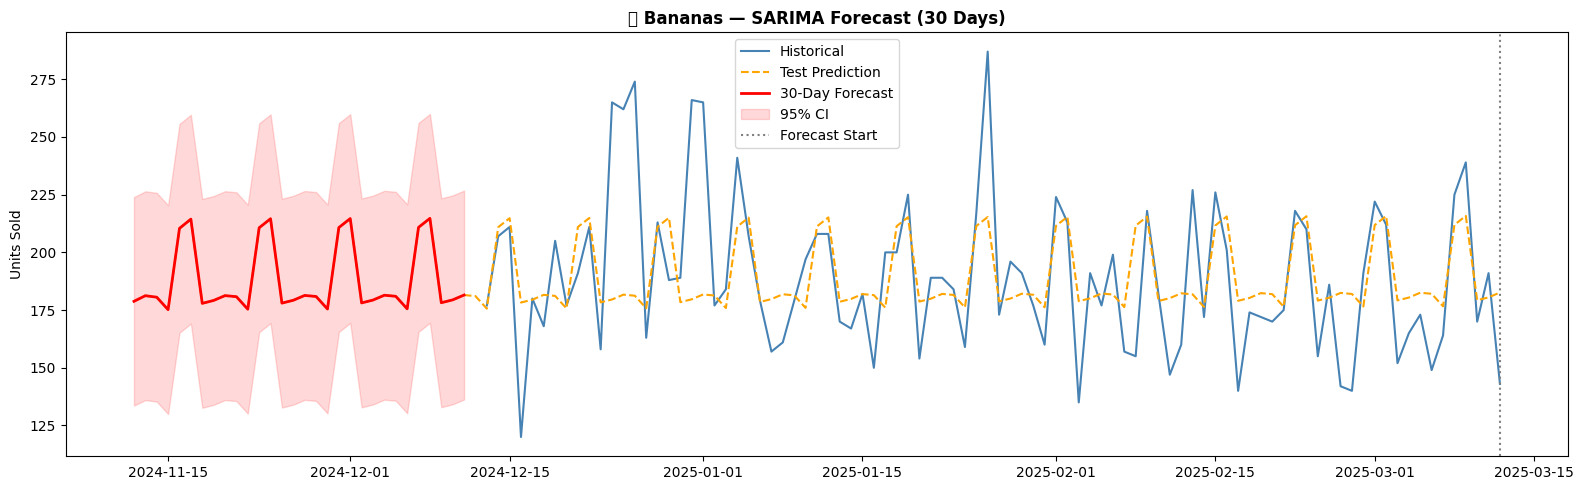

In [14]:
# ── ARIMA — Forecast Next 30 Days ────────────────────────────────
future_arima = sarima_fit.get_forecast(steps=FORECAST_DAYS)
future_mean  = future_arima.predicted_mean
future_ci    = future_arima.conf_int()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(prod_series[-90:], label='Historical', color='steelblue')
ax.plot(pred_arima_mean, label='Test Prediction', color='orange', linestyle='--')
ax.plot(future_mean, label='30-Day Forecast', color='red', linewidth=2)
ax.fill_between(future_ci.index, future_ci.iloc[:,0], future_ci.iloc[:,1],
                color='red', alpha=0.15, label='95% CI')
ax.axvline(prod_series.index[-1], color='gray', linestyle=':', linewidth=1.5, label='Forecast Start')
ax.set_title(f'📦 {FOCUS_PRODUCT} — SARIMA Forecast (30 Days)', fontweight='bold')
ax.set_ylabel('Units Sold')
ax.legend()
plt.tight_layout()
plt.show()

### 4B — XGBoost / Gradient Boosting (multi-product ML model)

In [15]:
try:
    import xgboost as xgb
    XGB_AVAILABLE = True
    print('✅ XGBoost available')
except ImportError:
    XGB_AVAILABLE = False
    print('⚠️  XGBoost not found — using GradientBoosting fallback')

✅ XGBoost available


In [16]:
# ── XGBoost Training ──────────────────────────────────────────────
FEATURE_COLS = [
    'lag_1','lag_3','lag_7','lag_14','lag_21','lag_30',
    'rolling_mean_7','rolling_mean_14','rolling_mean_30',
    'rolling_std_7','rolling_std_14','rolling_std_30',
    'rolling_max_7','rolling_max_14','rolling_max_30',
    'day_of_week','month','quarter','day_of_month',
    'week_of_year','is_weekend','is_month_end','is_month_start',
    'trend','trend_squared','product_enc','category_enc'
]
TARGET = 'Units_Sold'

# Time-based train/test split (last 15% = test)
split_date = feat_df['Date'].quantile(0.85)
split_date = pd.Timestamp(split_date)

train_xgb = feat_df[feat_df['Date'] <= split_date]
test_xgb  = feat_df[feat_df['Date'] >  split_date]

X_train = train_xgb[FEATURE_COLS]
y_train = train_xgb[TARGET]
X_test  = test_xgb[FEATURE_COLS]
y_test  = test_xgb[TARGET]

print(f'Train samples: {len(X_train):,} | Test samples: {len(X_test):,}')
print(f'Split date   : {split_date.date()}')

# Model
if XGB_AVAILABLE:
    model_xgb = xgb.XGBRegressor(
        n_estimators=300, max_depth=6,
        learning_rate=0.08, subsample=0.85,
        colsample_bytree=0.85, min_child_weight=3,
        random_state=42, n_jobs=-1
    )
else:
    model_xgb = GradientBoostingRegressor(
        n_estimators=200, max_depth=5,
        learning_rate=0.1, subsample=0.85,
        random_state=42
    )

model_xgb.fit(X_train, y_train)
y_pred_xgb = model_xgb.predict(X_test)
y_pred_xgb = np.maximum(y_pred_xgb, 0)  # No negative predictions

xgb_mae  = mean_absolute_error(y_test, y_pred_xgb)
xgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
xgb_mape = np.mean(np.abs((y_test.values - y_pred_xgb) / np.maximum(y_test.values, 1))) * 100

model_name = 'XGBoost' if XGB_AVAILABLE else 'GradientBoosting'
print(f'\n📊 {model_name} Results (all products):')
print(f'   MAE  : {xgb_mae:.2f}')
print(f'   RMSE : {xgb_rmse:.2f}')
print(f'   MAPE : {xgb_mape:.2f}%')

Train samples: 21,024 | Test samples: 3,680
Split date   : 2024-11-17

📊 XGBoost Results (all products):
   MAE  : 16.01
   RMSE : 21.35
   MAPE : 15.86%


C:\Users\BAPS\AppData\Local\Temp\ipykernel_4556\2951613095.py:13: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\BAPS\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


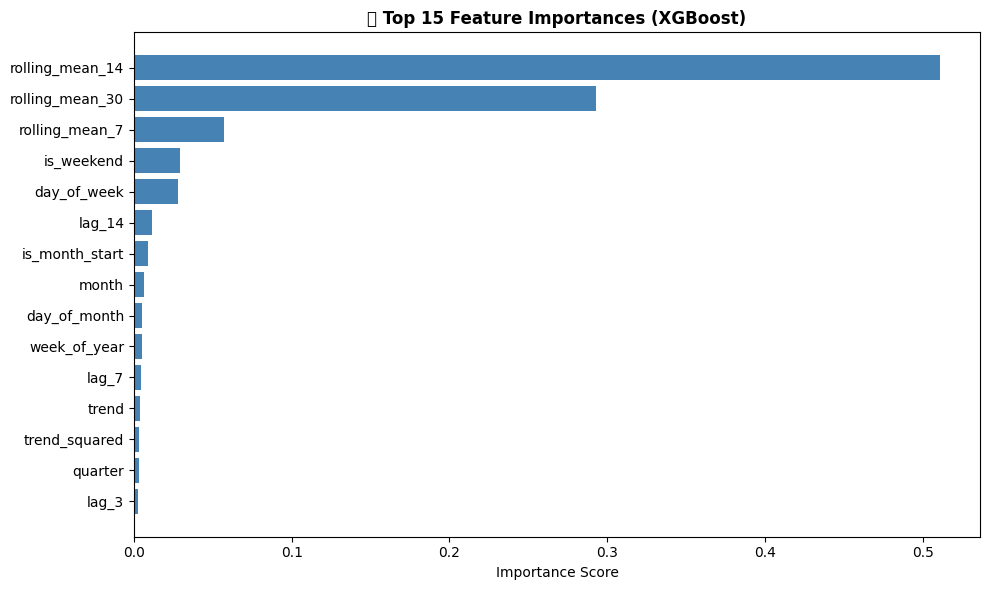

In [17]:
# ── Feature Importance ────────────────────────────────────────────
if XGB_AVAILABLE:
    importances = model_xgb.feature_importances_
else:
    importances = model_xgb.feature_importances_

feat_imp = pd.Series(importances, index=FEATURE_COLS).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(feat_imp.index[::-1], feat_imp.values[::-1], color='steelblue')
plt.title('🔍 Top 15 Feature Importances (XGBoost)', fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

C:\Users\BAPS\AppData\Local\Temp\ipykernel_4556\3636827182.py:11: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\BAPS\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


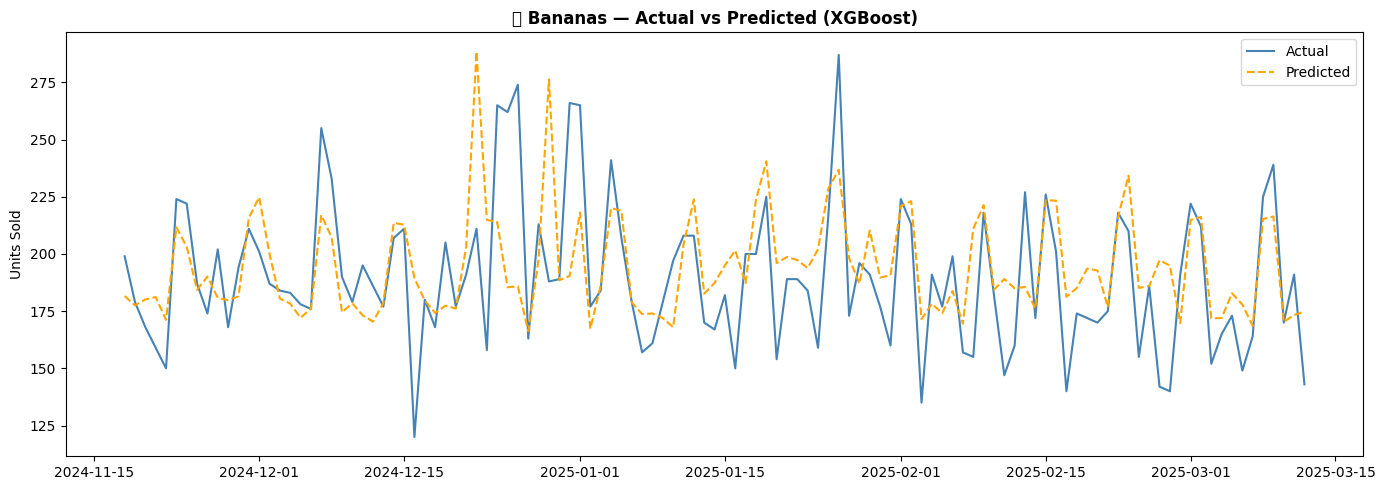

In [18]:
# ── Actual vs Predicted — One Product ────────────────────────────
prod_test = test_xgb[test_xgb['Product_Name'] == FOCUS_PRODUCT].copy()
prod_test_pred = model_xgb.predict(prod_test[FEATURE_COLS])

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(prod_test['Date'].values, prod_test['Units_Sold'].values, label='Actual', color='steelblue')
ax.plot(prod_test['Date'].values, np.maximum(prod_test_pred, 0), label='Predicted', color='orange', linestyle='--')
ax.set_title(f'📦 {FOCUS_PRODUCT} — Actual vs Predicted (XGBoost)', fontweight='bold')
ax.set_ylabel('Units Sold')
ax.legend()
plt.tight_layout()
plt.show()

### 4C — Prophet (if installed)

In [19]:
try:
    from prophet import Prophet
    PROPHET_AVAILABLE = True
    print('✅ Prophet available')
except ImportError:
    PROPHET_AVAILABLE = False
    print('⚠️  Prophet not installed — install with: pip install prophet')

c:\Users\BAPS\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Prophet available


16:02:33 - cmdstanpy - INFO - Chain [1] start processing
16:02:33 - cmdstanpy - INFO - Chain [1] done processing


📊 Prophet Results for Bananas:
   MAE  : 18.34
   RMSE : 25.21
   MAPE : 9.85%


C:\Users\BAPS\AppData\Local\Temp\ipykernel_4556\900398636.py:34: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\BAPS\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


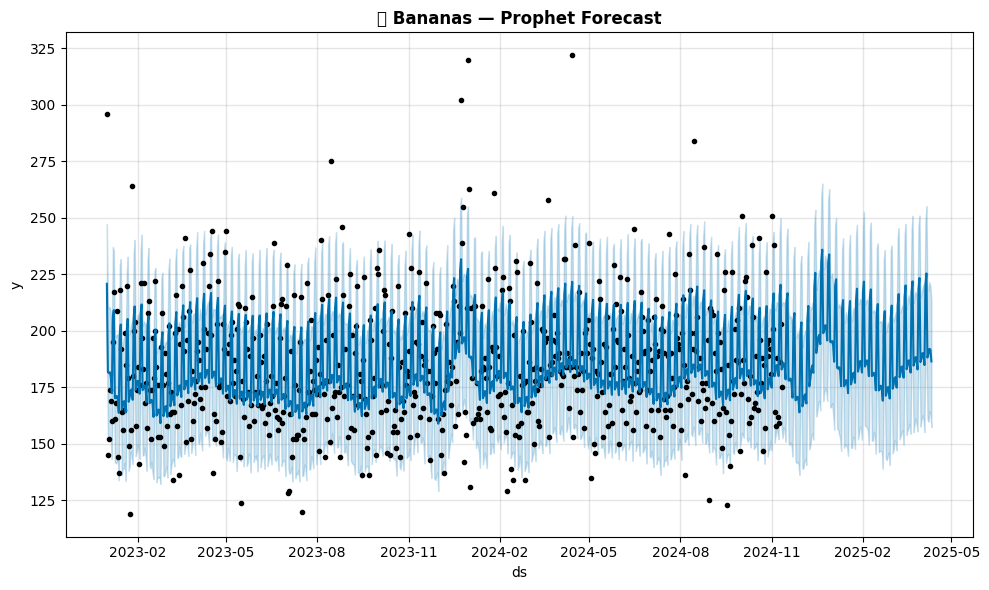

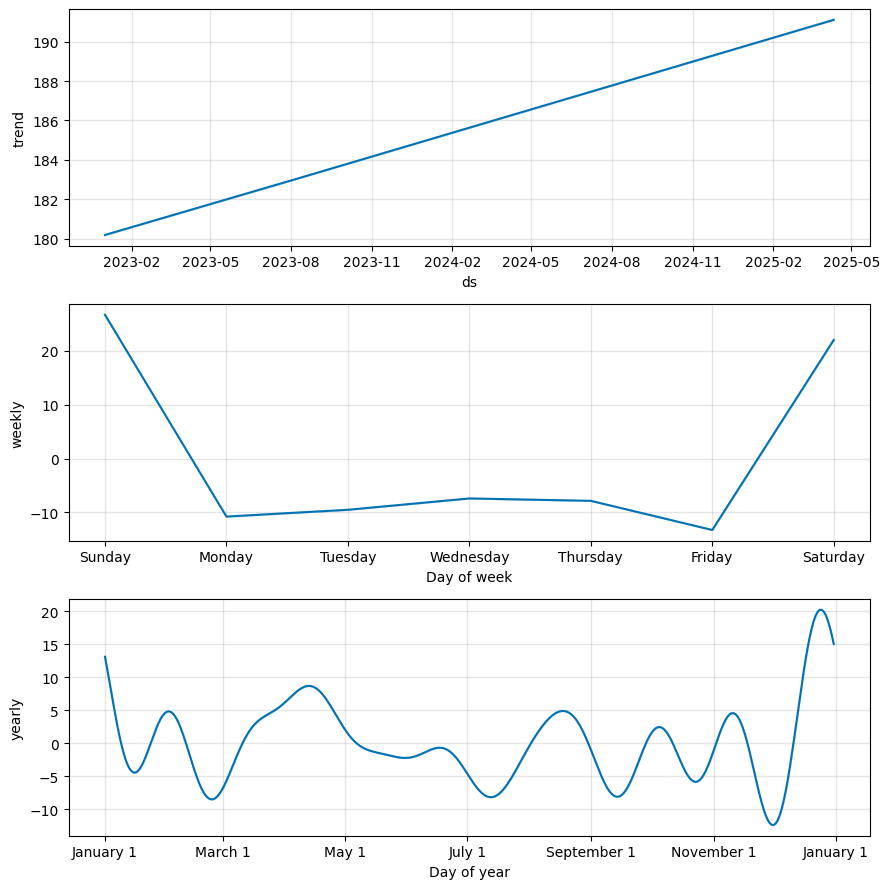

In [20]:
if PROPHET_AVAILABLE:
    prophet_df = df[df['Product_Name'] == FOCUS_PRODUCT][['Date','Units_Sold']].rename(
        columns={'Date':'ds', 'Units_Sold':'y'}
    ).reset_index(drop=True)

    split_idx = int(len(prophet_df) * 0.85)
    train_p   = prophet_df.iloc[:split_idx]
    test_p    = prophet_df.iloc[split_idx:]

    m = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        changepoint_prior_scale=0.05
    )
    m.fit(train_p)

    future = m.make_future_dataframe(periods=len(test_p) + FORECAST_DAYS)
    forecast = m.predict(future)

    pred_p = forecast.iloc[split_idx:split_idx+len(test_p)]['yhat'].values
    prophet_mae  = mean_absolute_error(test_p['y'].values, pred_p)
    prophet_rmse = np.sqrt(mean_squared_error(test_p['y'].values, pred_p))
    prophet_mape = np.mean(np.abs((test_p['y'].values - pred_p) / np.maximum(test_p['y'].values,1))) * 100

    print(f'📊 Prophet Results for {FOCUS_PRODUCT}:')
    print(f'   MAE  : {prophet_mae:.2f}')
    print(f'   RMSE : {prophet_rmse:.2f}')
    print(f'   MAPE : {prophet_mape:.2f}%')

    # Plot
    fig2 = m.plot(forecast)
    plt.title(f'📦 {FOCUS_PRODUCT} — Prophet Forecast', fontweight='bold')
    plt.tight_layout()
    plt.show()

    fig3 = m.plot_components(forecast)
    plt.tight_layout()
    plt.show()
else:
    print('⚠️  Prophet not installed. Run: pip install prophet')
    print('   Skipping Prophet model...')
    prophet_mae  = None
    prophet_rmse = None
    prophet_mape = None

## 📏 Phase 5: Model Evaluation & Comparison


📊 MODEL COMPARISON RESULTS
     Model       MAE      RMSE   MAPE        Scope
    SARIMA 17.304501 25.956805  9.19%  Per-product
XGBoost/GB 16.009230 21.347661 15.86% All products
   Prophet 18.339007 25.205811  9.85%  Per-product


C:\Users\BAPS\AppData\Local\Temp\ipykernel_4556\927489259.py:44: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\BAPS\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


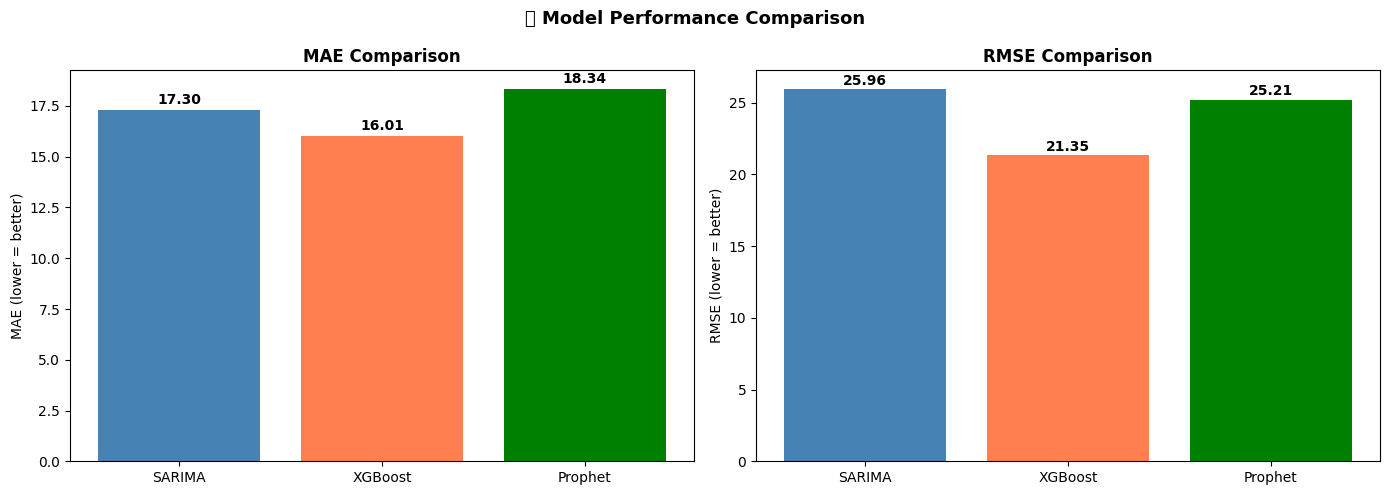


🏆 Best Model by MAE: XGBoost


In [21]:
# ── Model Comparison Table ────────────────────────────────────────
results = {
    'Model': ['SARIMA', 'XGBoost/GB', 'Prophet'],
    'MAE':   [arima_mae,  xgb_mae,  prophet_mae  if prophet_mae  else 'N/A'],
    'RMSE':  [arima_rmse, xgb_rmse, prophet_rmse if prophet_rmse else 'N/A'],
    'MAPE':  [f'{arima_mape:.2f}%', f'{xgb_mape:.2f}%',
              f'{prophet_mape:.2f}%' if prophet_mape else 'N/A'],
    'Scope': ['Per-product', 'All products', 'Per-product']
}

results_df = pd.DataFrame(results)
print('\n' + '='*65)
print('📊 MODEL COMPARISON RESULTS')
print('='*65)
print(results_df.to_string(index=False))
print('='*65)

# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models_plot = ['SARIMA', 'XGBoost']
mae_vals    = [arima_mae, xgb_mae]
rmse_vals   = [arima_rmse, xgb_rmse]

if PROPHET_AVAILABLE and prophet_mae:
    models_plot.append('Prophet')
    mae_vals.append(prophet_mae)
    rmse_vals.append(prophet_rmse)

colors = ['steelblue','coral','green'][:len(models_plot)]
axes[0].bar(models_plot, mae_vals, color=colors)
axes[0].set_title('MAE Comparison', fontweight='bold')
axes[0].set_ylabel('MAE (lower = better)')
for i, v in enumerate(mae_vals):
    axes[0].text(i, v + 0.3, f'{v:.2f}', ha='center', fontweight='bold')

axes[1].bar(models_plot, rmse_vals, color=colors)
axes[1].set_title('RMSE Comparison', fontweight='bold')
axes[1].set_ylabel('RMSE (lower = better)')
for i, v in enumerate(rmse_vals):
    axes[1].text(i, v + 0.3, f'{v:.2f}', ha='center', fontweight='bold')

plt.suptitle('🏆 Model Performance Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

best = models_plot[np.argmin(mae_vals)]
print(f'\n🏆 Best Model by MAE: {best}')

C:\Users\BAPS\AppData\Local\Temp\ipykernel_4556\2285696800.py:22: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\BAPS\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


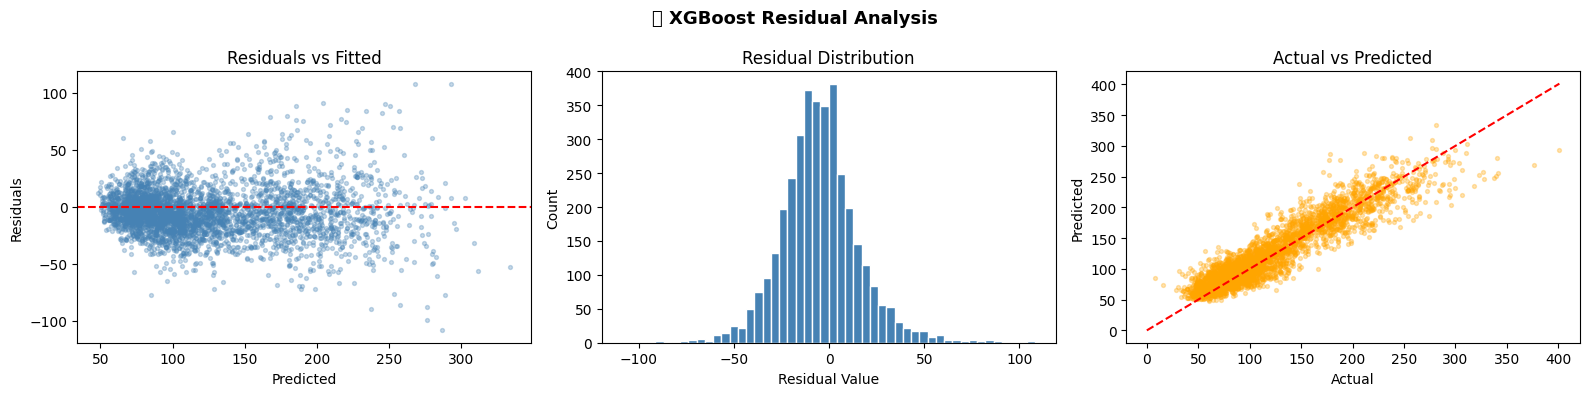

In [22]:
# ── Residual Analysis (XGBoost) ───────────────────────────────────
residuals = y_test.values - y_pred_xgb

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].scatter(y_pred_xgb, residuals, alpha=0.3, color='steelblue', s=8)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted')

axes[1].hist(residuals, bins=50, color='steelblue', edgecolor='white')
axes[1].set_xlabel('Residual Value'); axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution')

axes[2].scatter(y_test.values, y_pred_xgb, alpha=0.3, color='orange', s=8)
lims = [0, max(y_test.max(), y_pred_xgb.max())]
axes[2].plot(lims, lims, 'r--', linewidth=1.5)
axes[2].set_xlabel('Actual'); axes[2].set_ylabel('Predicted')
axes[2].set_title('Actual vs Predicted')

plt.suptitle('🔍 XGBoost Residual Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 🔧 Phase 6: Hyperparameter Tuning (Walk-Forward Cross-Validation)

In [23]:
from sklearn.model_selection import ParameterGrid

# ── Time-Series Walk-Forward Validation ──────────────────────────
def walk_forward_validation(model_class, params, data, feature_cols, target, n_splits=5):
    fold_size = len(data) // (n_splits + 1)
    maes = []
    for fold in range(n_splits):
        train_end_idx = fold_size * (fold + 1)
        test_end_idx  = train_end_idx + fold_size
        X_tr = data.iloc[:train_end_idx][feature_cols]
        y_tr = data.iloc[:train_end_idx][target]
        X_te = data.iloc[train_end_idx:test_end_idx][feature_cols]
        y_te = data.iloc[train_end_idx:test_end_idx][target]
        if len(X_te) == 0:
            continue
        m = model_class(**params)
        m.fit(X_tr, y_tr)
        preds = np.maximum(m.predict(X_te), 0)
        maes.append(mean_absolute_error(y_te, preds))
    return np.mean(maes)

# Parameter grid (small for speed)
if XGB_AVAILABLE:
    param_grid = {
        'n_estimators':  [100, 200],
        'max_depth':     [4, 6],
        'learning_rate': [0.05, 0.1],
        'subsample':     [0.8]
    }
    ModelClass = xgb.XGBRegressor
    extra = {'random_state': 42, 'n_jobs': -1}
else:
    param_grid = {
        'n_estimators':  [100, 150],
        'max_depth':     [4, 5],
        'learning_rate': [0.05, 0.1]
    }
    ModelClass = GradientBoostingRegressor
    extra = {'random_state': 42}

print(f'⏳ Grid search over {len(list(ParameterGrid(param_grid)))} combinations...')
best_mae, best_params = float('inf'), {}

for params in ParameterGrid(param_grid):
    combined = {**params, **extra}
    mae = walk_forward_validation(ModelClass, combined, feat_df, FEATURE_COLS, TARGET)
    if mae < best_mae:
        best_mae, best_params = mae, combined
    print(f'  Params: {params} → CV MAE: {mae:.2f}')

print(f'\n✅ Best Params : {best_params}')
print(f'   Best CV MAE : {best_mae:.2f}')

⏳ Grid search over 8 combinations...
  Params: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100, 'subsample': 0.8} → CV MAE: 15.25
  Params: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8} → CV MAE: 15.52
  Params: {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 100, 'subsample': 0.8} → CV MAE: 15.63
  Params: {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8} → CV MAE: 15.74
  Params: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 100, 'subsample': 0.8} → CV MAE: 15.55
  Params: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8} → CV MAE: 15.59
  Params: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 100, 'subsample': 0.8} → CV MAE: 16.21
  Params: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8} → CV MAE: 16.38

✅ Best Params : {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100, 'subsample': 0.8, 'random_state': 42, 'n_jobs': -

In [24]:
# ── Retrain with Best Params ──────────────────────────────────────
final_model = ModelClass(**best_params)
final_model.fit(X_train, y_train)

final_pred = np.maximum(final_model.predict(X_test), 0)
final_mae  = mean_absolute_error(y_test, final_pred)
final_rmse = np.sqrt(mean_squared_error(y_test, final_pred))
final_mape = np.mean(np.abs((y_test.values - final_pred) / np.maximum(y_test.values,1))) * 100

print('=' * 50)
print('📊 FINAL TUNED MODEL RESULTS')
print('=' * 50)
print(f'MAE  : {final_mae:.2f}  (baseline: {xgb_mae:.2f}, improvement: {(xgb_mae-final_mae)/xgb_mae*100:.1f}%)')
print(f'RMSE : {final_rmse:.2f}')
print(f'MAPE : {final_mape:.2f}%')
print('=' * 50)

📊 FINAL TUNED MODEL RESULTS
MAE  : 14.48  (baseline: 16.01, improvement: 9.5%)
RMSE : 19.92
MAPE : 13.89%


## 📈 Phase 7: Final Forecast & Business Insights

In [25]:
# ── Forecast Next 30 Days for All Products ────────────────────────
from datetime import timedelta

last_date     = df['Date'].max()
future_dates  = pd.date_range(start=last_date + timedelta(days=1), periods=FORECAST_DAYS)
all_forecasts = []

for product in df['Product_Name'].unique():
    prod_history = feat_df[feat_df['Product_Name'] == product].sort_values('Date').tail(30)
    if len(prod_history) < 30:
        continue

    last_row = prod_history.iloc[-1].copy()
    pcat     = last_row['category_enc']
    penc     = last_row['product_enc']
    
    recent_sales = prod_history['Units_Sold'].values
    daily_preds  = []

    for i, fdate in enumerate(future_dates):
        history_ext = np.concatenate([recent_sales, daily_preds])
        lag_vals    = {f'lag_{l}': history_ext[-(l)] if len(history_ext) >= l else np.mean(recent_sales)
                       for l in [1,3,7,14,21,30]}
        roll_vals   = {f'rolling_mean_{w}': np.mean(history_ext[-w:]) if len(history_ext)>=w else np.mean(recent_sales)
                       for w in [7,14,30]}
        roll_std    = {f'rolling_std_{w}':  np.std(history_ext[-w:])  if len(history_ext)>=w else np.std(recent_sales)
                       for w in [7,14,30]}
        roll_max    = {f'rolling_max_{w}':  np.max(history_ext[-w:])  if len(history_ext)>=w else np.max(recent_sales)
                       for w in [7,14,30]}

        row = {
            **lag_vals, **roll_vals, **roll_std, **roll_max,
            'day_of_week':    fdate.dayofweek,
            'month':          fdate.month,
            'quarter':        fdate.quarter,
            'day_of_month':   fdate.day,
            'week_of_year':   fdate.isocalendar()[1],
            'is_weekend':     int(fdate.dayofweek >= 5),
            'is_month_end':   int(fdate.is_month_end),
            'is_month_start': int(fdate.is_month_start),
            'trend':          len(feat_df[feat_df['Product_Name']==product]) + i,
            'trend_squared':  (len(feat_df[feat_df['Product_Name']==product]) + i) ** 2,
            'product_enc':    penc,
            'category_enc':   pcat
        }
        X_row = pd.DataFrame([row])[FEATURE_COLS]
        pred  = max(final_model.predict(X_row)[0], 0)
        daily_preds.append(pred)

    for d, p in zip(future_dates, daily_preds):
        cat = df[df['Product_Name']==product]['Category'].iloc[0]
        all_forecasts.append({'Product_Name': product, 'Category': cat,
                              'Date': d, 'Predicted_Demand': round(p, 1)})

forecast_df = pd.DataFrame(all_forecasts)
print(f'✅ Forecasted {forecast_df["Product_Name"].nunique()} products × {FORECAST_DAYS} days')
print(f'   Total forecast rows: {len(forecast_df):,}')
forecast_df.head(10)

✅ Forecasted 32 products × 30 days
   Total forecast rows: 960


,Product_Name,Category,Date,Predicted_Demand
0,Bananas,Fruits & Vegetables,2025-03-13,176.699997
1,Bananas,Fruits & Vegetables,2025-03-14,184.600006
2,Bananas,Fruits & Vegetables,2025-03-15,216.699997
3,Bananas,Fruits & Vegetables,2025-03-16,219.899994
4,Bananas,Fruits & Vegetables,2025-03-17,176.800003
5,Bananas,Fruits & Vegetables,2025-03-18,180.600006
6,Bananas,Fruits & Vegetables,2025-03-19,178.500000
7,Bananas,Fruits & Vegetables,2025-03-20,177.800003
8,Bananas,Fruits & Vegetables,2025-03-21,185.800003
9,Bananas,Fruits & Vegetables,2025-03-22,223.399994


C:\Users\BAPS\AppData\Local\Temp\ipykernel_4556\221785856.py:20: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\BAPS\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


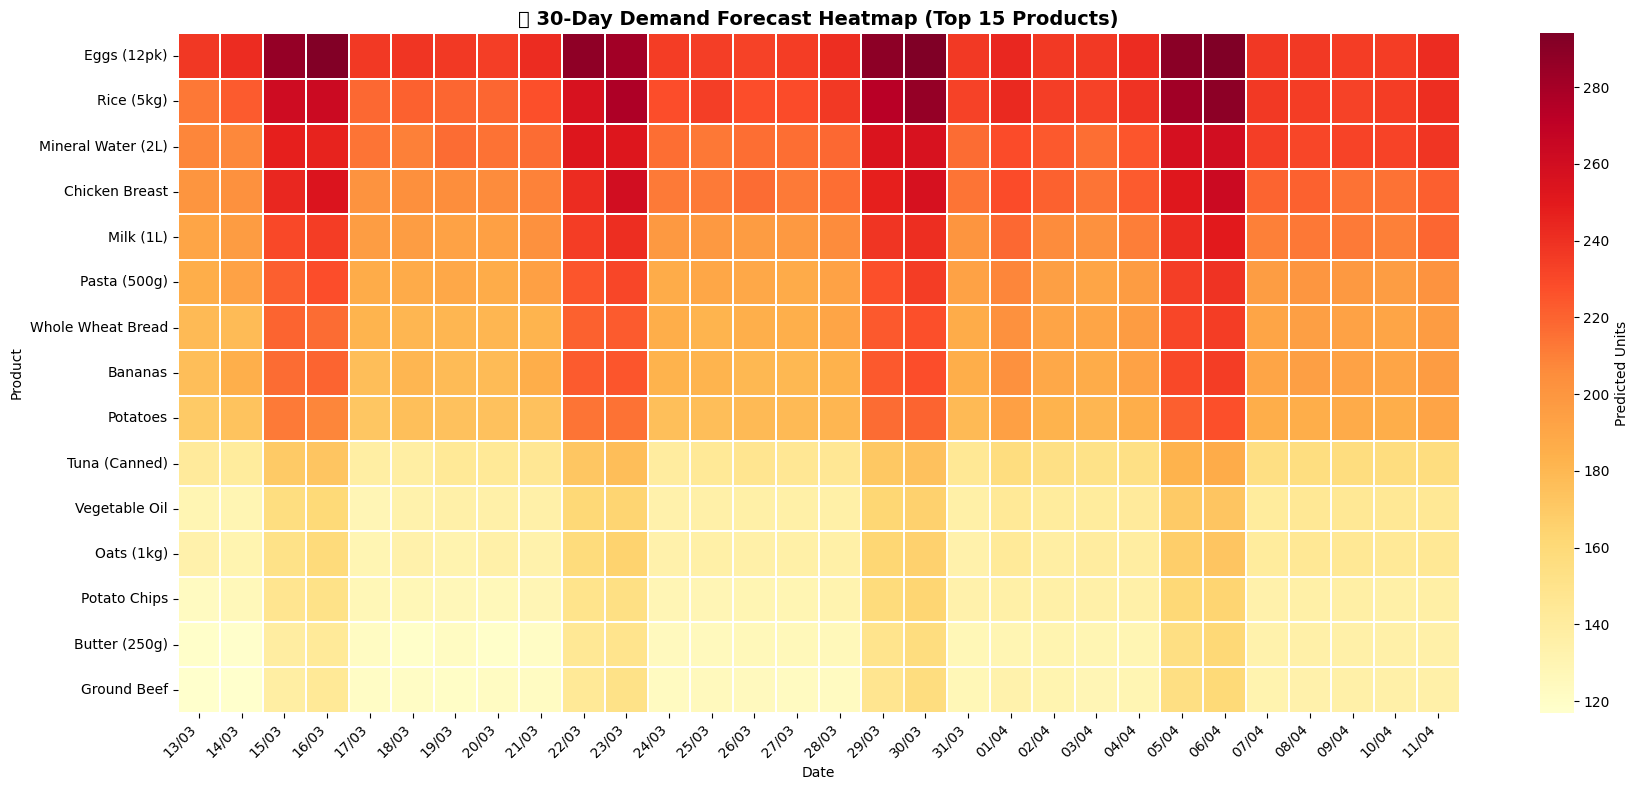

In [26]:
# ── Forecast Heatmap (Top 15 Products) ───────────────────────────
pivot = forecast_df.pivot_table(
    index='Product_Name', columns='Date', values='Predicted_Demand'
).round(0)

# Show top 15 by total predicted demand
top15 = forecast_df.groupby('Product_Name')['Predicted_Demand'].sum().nlargest(15).index
pivot_top = pivot.loc[top15]

# Simplify column labels to just date
pivot_top.columns = pivot_top.columns.strftime('%d/%m')

plt.figure(figsize=(18, 8))
sns.heatmap(pivot_top, annot=False, fmt='.0f', cmap='YlOrRd',
            linewidths=0.3, linecolor='white', cbar_kws={'label': 'Predicted Units'})
plt.title('🔥 30-Day Demand Forecast Heatmap (Top 15 Products)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Product')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [27]:
# ── Business Insights ─────────────────────────────────────────────
print('=' * 60)
print('💼 BUSINESS INSIGHTS — INVENTORY RECOMMENDATIONS')
print('=' * 60)

# 1. Top 5 high-demand products next 30 days
total_demand = forecast_df.groupby('Product_Name')['Predicted_Demand'].sum().sort_values(ascending=False)
print('\n🏆 Top 5 High Demand Products (Next 30 Days):')
for prod, demand in total_demand.head(5).items():
    print(f'   {prod:30s}  →  {demand:,.0f} units')

# 2. Category-level demand
cat_demand = forecast_df.groupby('Category')['Predicted_Demand'].sum().sort_values(ascending=False)
print('\n📦 Category-wise 30-Day Forecast:')
for cat, demand in cat_demand.items():
    print(f'   {cat:35s}  →  {demand:,.0f} units')

# 3. Peak demand days
daily_demand = forecast_df.groupby('Date')['Predicted_Demand'].sum()
peak_day  = daily_demand.idxmax()
low_day   = daily_demand.idxmin()
print(f'\n📈 Peak Demand Day  : {peak_day.date()} ({daily_demand.max():,.0f} units)')
print(f'📉 Lowest Demand Day: {low_day.date()}  ({daily_demand.min():,.0f} units)')

# 4. Weekend vs weekday
forecast_df['is_weekend'] = forecast_df['Date'].dt.dayofweek >= 5
wknd = forecast_df.groupby('is_weekend')['Predicted_Demand'].mean()
print(f'\n📅 Weekday Avg Demand : {wknd.get(False, 0):.1f} units/product/day')
print(f'📅 Weekend Avg Demand : {wknd.get(True, 0):.1f} units/product/day')
print('=' * 60)

💼 BUSINESS INSIGHTS — INVENTORY RECOMMENDATIONS

🏆 Top 5 High Demand Products (Next 30 Days):
   Eggs (12pk)                     →  7,539 units
   Rice (5kg)                      →  7,244 units
   Mineral Water (2L)              →  6,873 units
   Chicken Breast                  →  6,710 units
   Milk (1L)                       →  6,384 units

📦 Category-wise 30-Day Forecast:
   Fruits & Vegetables                  →  23,914 units
   Grains & Staples                     →  23,585 units
   Dairy & Eggs                         →  20,800 units
   Meat & Seafood                       →  18,461 units
   Beverages                            →  13,709 units
   Oils & Fats                          →  10,977 units
   Snacks & Confectionery               →  9,932 units
   Frozen Foods                         →  7,185 units
   Condiments & Spices                  →  7,123 units

📈 Peak Demand Day  : 2025-04-06 (5,403 units)
📉 Lowest Demand Day: 2025-03-13  (4,056 units)

📅 Weekday Avg Demand : 134

C:\Users\BAPS\AppData\Local\Temp\ipykernel_4556\676783598.py:21: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\BAPS\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


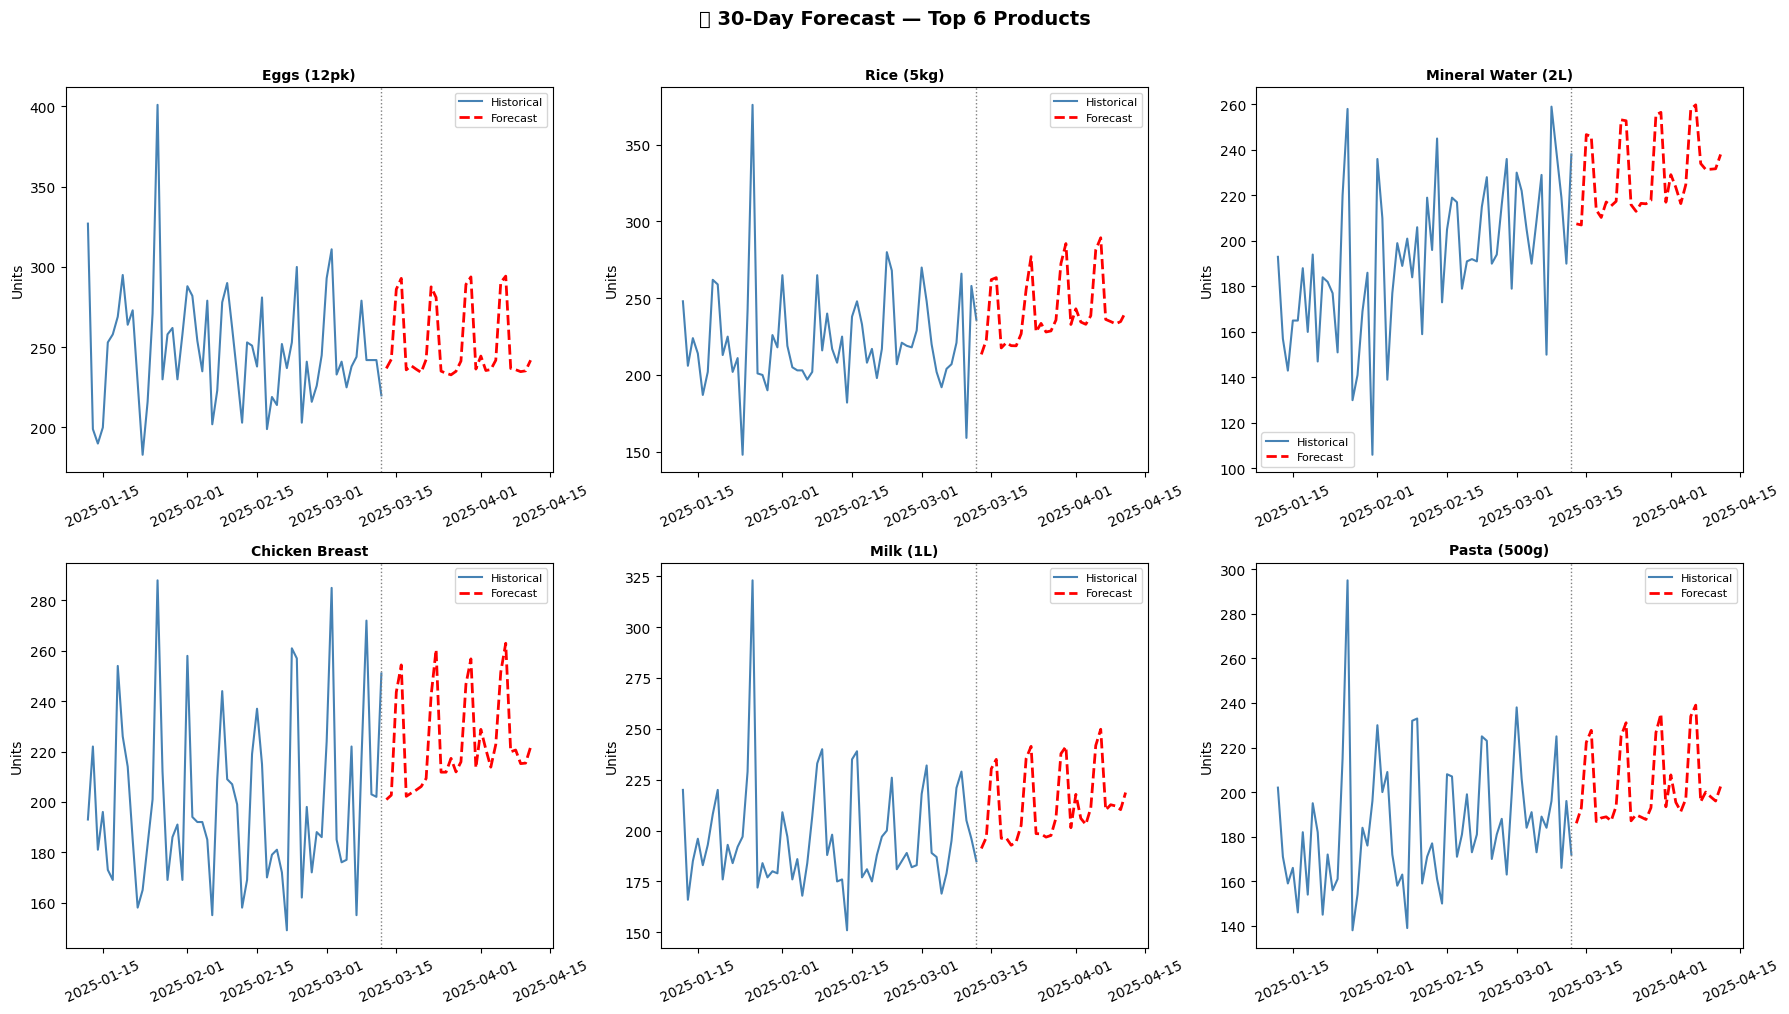

In [28]:
# ── Forecast Chart — Top 6 Products ──────────────────────────────
top6_products = total_demand.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, product in enumerate(top6_products):
    hist = df[df['Product_Name'] == product][['Date','Units_Sold']].tail(60)
    fcst = forecast_df[forecast_df['Product_Name'] == product]

    axes[i].plot(hist['Date'], hist['Units_Sold'], color='steelblue', label='Historical', linewidth=1.5)
    axes[i].plot(fcst['Date'], fcst['Predicted_Demand'], color='red',
                 label='Forecast', linewidth=2, linestyle='--')
    axes[i].axvline(last_date, color='gray', linestyle=':', linewidth=1)
    axes[i].set_title(f'{product}', fontweight='bold', fontsize=10)
    axes[i].set_ylabel('Units')
    axes[i].tick_params(axis='x', rotation=25)
    axes[i].legend(fontsize=8)

plt.suptitle('📈 30-Day Forecast — Top 6 Products', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [29]:
import os, json

os.makedirs('models', exist_ok=True)
os.makedirs('outputs', exist_ok=True)

# ── Save ML Model ─────────────────────────────────────────────────
joblib.dump(final_model, 'models/inventory_xgb_model.pkl')
joblib.dump(le_product,  'models/label_encoder_product.pkl')
joblib.dump(le_category, 'models/label_encoder_category.pkl')
print('✅ Model saved: models/inventory_xgb_model.pkl')

# ── Save SARIMA Model ─────────────────────────────────────────────
sarima_fit.save('models/sarima_bananas.pkl')
print('✅ SARIMA saved: models/sarima_bananas.pkl')

# ── Export Forecast CSV ───────────────────────────────────────────
forecast_df.to_csv('outputs/30_day_forecast.csv', index=False)
print('✅ Forecast exported: outputs/30_day_forecast.csv')

# ── Save Model Metadata ───────────────────────────────────────────
metadata = {
    'model_type': 'XGBoost' if XGB_AVAILABLE else 'GradientBoosting',
    'best_params': str(best_params),
    'test_mae': round(final_mae, 3),
    'test_rmse': round(final_rmse, 3),
    'test_mape': round(final_mape, 3),
    'features': FEATURE_COLS,
    'products': list(df['Product_Name'].unique()),
    'train_date_range': f'{df["Date"].min().date()} to {df["Date"].max().date()}',
    'forecast_days': FORECAST_DAYS
}

with open('models/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print('✅ Metadata saved: models/model_metadata.json')
print('\n' + '='*55)
print('🎉 PROJECT COMPLETE!')
print('='*55)
print(f'  Model Type : {metadata["model_type"]}')
print(f'  Test MAE   : {final_mae:.2f}')
print(f'  Test MAPE  : {final_mape:.2f}%')
print(f'  Products   : {df["Product_Name"].nunique()}')
print(f'  Forecast   : {FORECAST_DAYS} days ahead')
print('='*55)

✅ Model saved: models/inventory_xgb_model.pkl
✅ SARIMA saved: models/sarima_bananas.pkl
✅ Forecast exported: outputs/30_day_forecast.csv
✅ Metadata saved: models/model_metadata.json

🎉 PROJECT COMPLETE!
  Model Type : XGBoost
  Test MAE   : 14.48
  Test MAPE  : 13.89%
  Products   : 32
  Forecast   : 30 days ahead


---
## 📋 Project Summary

| Phase | Description | Status |
|-------|-------------|--------|
| 1 | Data Loading & Exploration | ✅ |
| 2 | EDA & Visualization | ✅ |
| 3 | Feature Engineering (lag, rolling, calendar) | ✅ |
| 4 | Model Building (SARIMA + XGBoost + Prophet) | ✅ |
| 5 | Model Evaluation (MAE, RMSE, MAPE) | ✅ |
| 6 | Hyperparameter Tuning (Walk-Forward CV) | ✅ |
| 7 | 30-Day Forecast + Business Insights | ✅ |
| 8 | Model Saving + Export | ✅ |

### Files Generated
- `models/inventory_xgb_model.pkl` — Trained ML model
- `models/sarima_bananas.pkl` — SARIMA model
- `models/model_metadata.json` — Model info & metrics
- `outputs/30_day_forecast.csv` — Final forecast for all products

### Next Steps
- Deploy model with **FastAPI** (`POST /predict`)
- Build **Streamlit** dashboard for visualization
- Set up **MLflow** for experiment tracking
- Schedule **weekly retraining** pipeline

In [36]:
## 🧪 Multiple Use Cases Testing

# Check what df contains
print("df columns:", df.columns.tolist())
print("df shape:", df.shape)

# Load original data for product info
DATA_PATH = 'inventory_forecast_dataset_v2.csv'
original_df = pd.read_csv(DATA_PATH, parse_dates=['Date'])
print("Original df columns:", original_df.columns.tolist())

# Check available products from original data
print("Available products in the dataset:")
available_products = original_df['Product_Name'].unique()
print(f"Total products: {len(available_products)}")
print("First 10 products:", available_products[:10])

# Check data count per product
product_counts = original_df.groupby('Product_Name').size().sort_values(ascending=False)
print("\nProduct data counts (top 10):")
print(product_counts.head(10))

# Define test cases for different scenarios using available products
test_cases = [
    {"product": "Bananas", "forecast_days": 7, "description": "Short-term forecast for high-demand product"},
    {"product": "Bananas", "forecast_days": 30, "description": "Long-term forecast for high-demand product"},
    {"product": product_counts.index[1] if len(product_counts) > 1 else "Bananas", "forecast_days": 15, "description": "Medium-term forecast for second most common product"},
    {"product": product_counts.index[2] if len(product_counts) > 2 else "Bananas", "forecast_days": 10, "description": "Forecast for third most common product"},
    {"product": "Bananas", "forecast_days": 3, "description": "Very short-term forecast"}
]

# Run all test cases
test_results = {}
for case in test_cases:
    result = run_test_case(case["product"], case["forecast_days"], case["description"])
    if result is not None:
        test_results[f"{case['product']}_{case['forecast_days']}d"] = result

print("\n=== Test Summary ===")
for key, df_result in test_results.items():
    print(f"{key}: {len(df_result)} days forecast completed")

# Additional validation: Compare with historical averages
print("\n=== Validation against Historical Data ===")
for product in available_products[:3]:  # Test first 3 products
    prod_data = original_df[original_df['Product_Name'] == product]
    if len(prod_data) > 30:
        historical_avg = prod_data['Units_Sold'].tail(30).mean()
        print(f"{product}: Historical 30-day avg = {historical_avg:.1f}")

df columns: ['Date', 'Predicted_Demand']
df shape: (3, 2)
Original df columns: ['Product_Name', 'Category', 'Date', 'Units_Sold']
Available products in the dataset:
Total products: 32
First 10 products: ['Bananas' 'Bell Pepper' 'Butter (250g)' 'Cheddar Cheese' 'Chicken Breast'
 'Cumin Powder' 'Dark Chocolate' 'Eggs (12pk)' 'Frozen Peas (500g)'
 'Frozen Pizza']

Product data counts (top 10):
Product_Name
Bananas               802
Bell Pepper           802
Butter (250g)         802
Cheddar Cheese        802
Chicken Breast        802
Cumin Powder          802
Dark Chocolate        802
Eggs (12pk)           802
Frozen Peas (500g)    802
Frozen Pizza          802
dtype: int64

--- Testing: Short-term forecast for high-demand product ---
Product: Bananas, Forecast Days: 7
Total predicted demand: 1333.7
Average daily demand: 190.5
Peak demand: 219.9

--- Testing: Long-term forecast for high-demand product ---
Product: Bananas, Forecast Days: 30
Total predicted demand: 5894.1
Average daily dem